TensorFlow version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset loaded successfully.
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


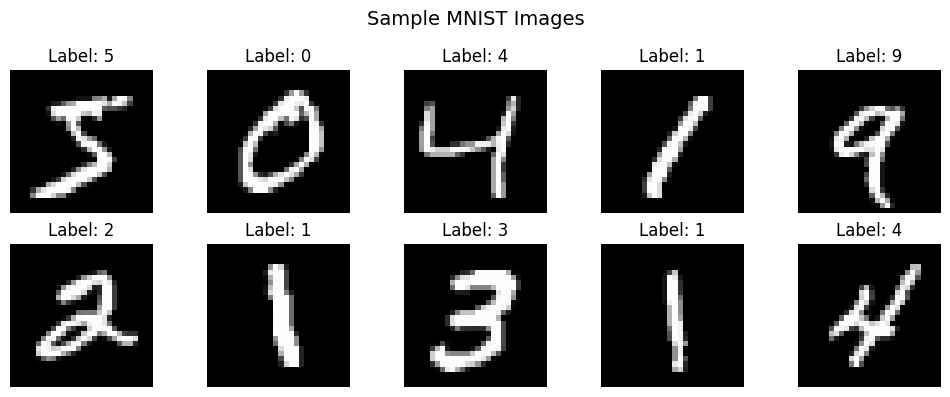


After preprocessing:
Training images: (60000, 28, 28, 1)
Testing images : (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



================ CNN MODEL ARCHITECTURE ================



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)


================ TRAINING MODEL ================

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.9389 - loss: 0.2001 - val_accuracy: 0.9840 - val_loss: 0.0528
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9837 - loss: 0.0529 - val_accuracy: 0.9770 - val_loss: 0.0687
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.9879 - loss: 0.0390 - val_accuracy: 0.9900 - val_loss: 0.0353
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9903 - val_loss: 0.0353
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9923 - loss: 0.0239 - val_accuracy: 0.9915 - val_loss: 0.0341

================ MODEL EVALUATION ================

Test Loss     : 0.0320
Test Accuracy : 98.97%


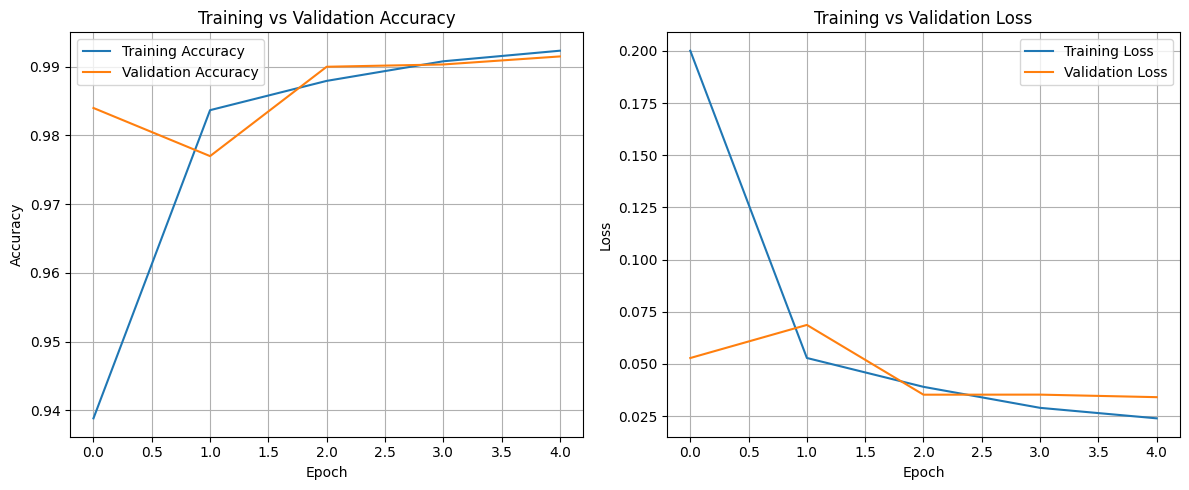

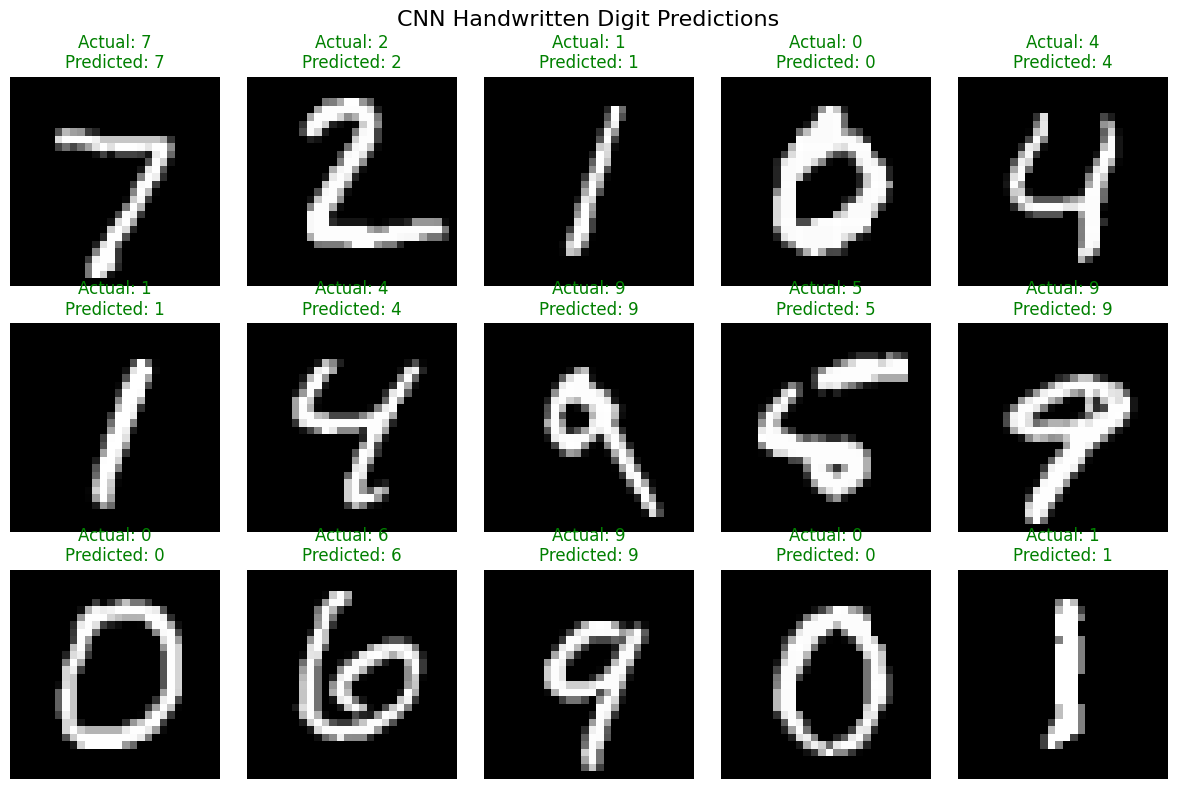


================ SINGLE IMAGE PREDICTION ================

Actual digit   : 7
Predicted digit: 7

Prediction probabilities:
Digit 0: 0.00%
Digit 1: 0.00%
Digit 2: 0.00%
Digit 3: 0.00%
Digit 4: 0.00%
Digit 5: 0.00%
Digit 6: 0.00%
Digit 7: 100.00%
Digit 8: 0.00%
Digit 9: 0.00%


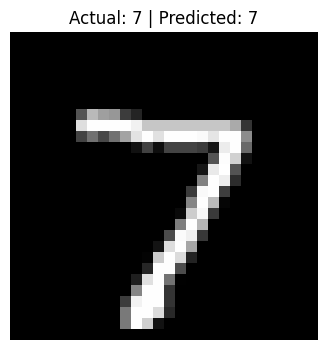


================ FINAL RESULTS ================

Total test images       : 10000
Correct predictions     : 9897
Incorrect predictions   : 103
Overall test accuracy   : 98.97%


In [1]:
#23070521141,Shivansh lohani

# 1. IMPORT REQUIRED LIBRARIES


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist


print("TensorFlow version:", tf.__version__)



# 2. LOAD THE MNIST DATASET


# MNIST contains 70,000 grayscale images of handwritten digits.
# Training set:
#   60,000 images
# Testing set:
#   10,000 images
# Each image has dimensions:
#   28 x 28 pixels
# The labels are digits from 0 to 9.

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("\nDataset loaded successfully.")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", x_test.shape)
print("Testing labels :", y_test.shape)


# 3. DISPLAY SOME ORIGINAL MNIST IMAGES

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

# 4. PREPROCESS THE DATA

# CNN expects images in the following format:
#
# (number_of_images, height, width, channels)
#
# Currently the images have:
#
# (number_of_images, 28, 28)
#
# Since MNIST images are grayscale, they have only one channel.
# Therefore, reshape them to:
#
# (number_of_images, 28, 28, 1)

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


# Convert pixel values from 0-255 to 0-1.
#
# Neural networks generally train better when input values
# are normalized to a small range.

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


print("\nAfter preprocessing:")
print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)


# 5. BUILD THE CNN MODEL

# Create a Sequential CNN model.

model = models.Sequential([

    # --------------------------------------------------------
    # Convolutional Layer 1
    # --------------------------------------------------------
    # 32 filters
    # Kernel size = 3 x 3
    # ReLU activation introduces non-linearity.
    #
    # Input image size = 28 x 28 x 1
    # --------------------------------------------------------

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Reduce spatial dimensions.
    # 2x2 max pooling keeps important features while reducing
    # computational complexity.

    layers.MaxPooling2D((2, 2)),


    # --------------------------------------------------------
    # Convolutional Layer 2
    # --------------------------------------------------------

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),


    # --------------------------------------------------------
    # Convolutional Layer 3
    # --------------------------------------------------------
    # This layer learns more complex patterns such as
    # curves, edges, and combinations of shapes.

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),


    # --------------------------------------------------------
    # Flatten
    # --------------------------------------------------------
    # Converts the 2D feature maps into a 1D vector so that
    # they can be passed to fully connected layers.

    layers.Flatten(),


    # --------------------------------------------------------
    # Fully Connected Layer
    # --------------------------------------------------------

    layers.Dense(
        64,
        activation="relu"
    ),


    # --------------------------------------------------------
    # Output Layer
    # --------------------------------------------------------
    # MNIST has 10 classes: digits 0 through 9.
    #
    # Softmax converts the outputs into probabilities.

    layers.Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 6. DISPLAY CNN ARCHITECTURE
# ============================================================

print("\n================ CNN MODEL ARCHITECTURE ================\n")

model.summary()


# ============================================================
# 7. COMPILE THE MODEL
# ============================================================

# Adam optimizer adjusts the weights during training.
#
# sparse_categorical_crossentropy is appropriate because
# our labels are integers such as 0, 1, 2, ..., 9.
#
# Accuracy tells us the percentage of correctly classified
# images.

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 8. TRAIN THE CNN MODEL
# ============================================================

print("\n================ TRAINING MODEL ================\n")

history = model.fit(
    x_train,
    y_train,

    # Number of complete passes through the training data.
    epochs=5,

    # Number of images processed at one time.
    batch_size=64,

    # Use 10% of training data for validation.
    validation_split=0.1,

    # Display training progress.
    verbose=1
)


# ============================================================
# 9. EVALUATE THE MODEL ON TEST DATA
# ============================================================

print("\n================ MODEL EVALUATION ================\n")

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


# ============================================================
# 10. PLOT TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


# ============================================================
# 11. PLOT TRAINING AND VALIDATION LOSS
# ============================================================

plt.subplot(1, 2, 2)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 12. MAKE PREDICTIONS
# ============================================================

# Use the trained CNN to predict the test images.

predictions = model.predict(x_test, verbose=0)


# predictions contains probabilities for all 10 digits.
#
# Example:
# [0.01, 0.02, 0.90, 0.01, ...]
#
# np.argmax() selects the class having the highest probability.

predicted_labels = np.argmax(predictions, axis=1)


# ============================================================
# 13. DISPLAY PREDICTION RESULTS
# ============================================================

plt.figure(figsize=(12, 8))

# Display 15 test images.

for i in range(15):

    plt.subplot(3, 5, i + 1)

    # x_test has shape (28, 28, 1), so remove the channel
    # dimension when displaying the image.

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    actual = y_test[i]
    predicted = predicted_labels[i]

    # Green = correct prediction
    # Red = incorrect prediction

    if actual == predicted:
        color = "green"
    else:
        color = "red"

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color=color
    )

    plt.axis("off")

plt.suptitle(
    "CNN Handwritten Digit Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. DISPLAY PREDICTION PROBABILITIES
# ============================================================

# Select one test image.

sample_index = 0

sample_image = x_test[sample_index]
sample_prediction = predictions[sample_index]

predicted_digit = np.argmax(sample_prediction)

print("\n================ SINGLE IMAGE PREDICTION ================\n")

print("Actual digit   :", y_test[sample_index])
print("Predicted digit:", predicted_digit)

print("\nPrediction probabilities:")

for digit in range(10):
    print(
        f"Digit {digit}: "
        f"{sample_prediction[digit] * 100:.2f}%"
    )


# Display the selected image.

plt.figure(figsize=(4, 4))

plt.imshow(
    sample_image.reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Actual: {y_test[sample_index]} | "
    f"Predicted: {predicted_digit}"
)

plt.axis("off")
plt.show()


# ============================================================
# 15. CALCULATE OVERALL PREDICTION ACCURACY MANUALLY
# ============================================================

correct_predictions = np.sum(
    predicted_labels == y_test
)

total_predictions = len(y_test)

manual_accuracy = (
    correct_predictions / total_predictions
) * 100

print("\n================ FINAL RESULTS ================\n")

print("Total test images       :", total_predictions)
print("Correct predictions     :", correct_predictions)
print("Incorrect predictions   :", total_predictions - correct_predictions)
print(f"Overall test accuracy   : {manual_accuracy:.2f}%")


# ============================================================
# END OF EXPERIMENT
# ============================================================